In [1]:
import numpy as np
import matplotlib.pyplot as plt
import RF_Track
import csv
from YAG_RCF_analysis import *
from topas2numpy import BinnedResult
import os
from CLEAR_line import *
from partrec_gaussian_optimiser_utils import partrec_gaussian_optimiser_utils
from topasToDose import getDosemap
from uniformity_fit import *
from partrec_foil_plotting import partrec_foil_plotting
from RF_track_utils import *
import sys


RF-Track, version 2.7.3

Copyright (C) 2016-2026 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.11



[RF-Track] Could not check for updates.


In [2]:
def get_bin_edges(dim):
    return np.linspace(0, dim.n_bins * dim.bin_width, dim.n_bins + 1)

3.4799999999999995


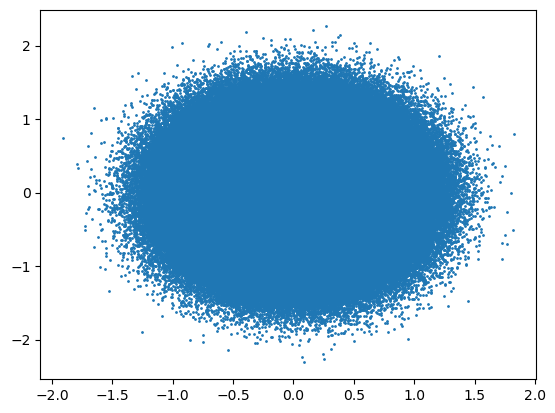

In [3]:

dir = '/Users/sabrinawang/Desktop/DPhil_Project/'
mass = RF_Track.electronmass    # particle mass in MeV/c^2
population = 10 * RF_Track.nC               # number of particles per bunch
Q = -1                          # particle charge in e units
  
n_particles = int(3e6)
RFT_name = "CLEAR_line"


start = 'CA.QFD0350' #'CA.ACS0270S_MECH'
end = 'CA.DHJ0840' #'CA.STLINE$END'



# Twiss parameters
# They are the ones at the starting point of your constructed lattice

Twiss = RF_Track.Bunch6d_twiss()
# twiss 13_05 before irradiations
# P_ref = 199.2
# Twiss.beta_x = 47.1        # m
# Twiss.beta_y = 37.8     # m
# Twiss.alpha_x = -4.49 
# Twiss.alpha_y = -3.89
# Twiss.emitt_x = 18.1     # mm.mrad normalised emittance
# Twiss.emitt_y = 22.3     # mm.mrad
# CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt",start, end, P_ref, np.array([11, 32, 22, 19, 39.4, 18,54.5,94.3,4]))

# twiss 13_05 from 875 quad scan at 760
# Twiss.beta_x = 9.34        # m
# Twiss.beta_y = 1.45    # m
# Twiss.alpha_x = 1.00
# Twiss.alpha_y = 0.78
# Twiss.emitt_x = 27.53    # mm.mrad normalised emittance
# Twiss.emitt_y = 38.70    # mm.mrad
# CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt","CA.QFD0760", end, P_ref, np.array([11, 32, 22, 19, 39.4, 18,54.5, 94.3, 4,0,0]))


#twiss 15_05 before irradiations
# P_ref = 197.3
# Twiss.beta_x = 40.5        # m
# Twiss.beta_y = 36.8     # m
# Twiss.alpha_x = -3.97 
# Twiss.alpha_y = -4.27
# Twiss.emitt_x = 22.8     # mm.mrad normalised emittance
# Twiss.emitt_y = 23.8     # mm.mrad
# # Twiss.sigma_t = 10 * RF_Track.ps       # mm/c   or 37 * RF_Track.ps
# # Twiss.sigma_pt = 10     # permille
# Twiss.mean_xp = 0.0
# Twiss.mean_yp = 0.0
# CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt",start, end, P_ref, np.array([11, 32, 22, 19, 32, 18, 0, 67.5, 100, 0, 0]))

# #twiss from 875 quad scan, at 760
# Twiss.beta_x = 0.65        # m
# Twiss.beta_y = 30.20    # m
# Twiss.alpha_x = -0.20
# Twiss.alpha_y = -1.87
# Twiss.emitt_x = 66.26     # mm.mrad normalised emittance
# Twiss.emitt_y = 86.26

# CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt","CA.QFD0760", end, P_ref, np.array([11, 32, 22, 19, 32, 18, 0, 67.5, 100, 0, 0]))



# #twiss 20_08_2026 from 390 quad scan, at 350
# Twiss.beta_x = 12.5        # m
# Twiss.beta_y =  39.3   # m
# Twiss.alpha_x = -1.6
# Twiss.alpha_y = -4
# Twiss.emitt_x = 17.0     # mm.mrad normalised emittance
# Twiss.emitt_y = 27.1

# CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt",start, end, P_ref, np.array([13, 21.5, 6, 0, 0.2, 0.1, 47.8, 81.9, 42.8, 0, 0]))
# CLEAR_quads = CLEAR_lattice.get_quadrupoles()

#  #twiss from 875 scan at 760, 2008
# P_ref = 193.4
# Twiss.beta_x = 14.95       # m
# Twiss.beta_y = 14.81   # m
# Twiss.alpha_x = -1.20
# Twiss.alpha_y = -0.43
# Twiss.emitt_x = 73.69    # mm.mrad normalised emittance
# Twiss.emitt_y = 95.97
# CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt","CA.QFD0760", end, P_ref, np.array([13, 21.5, 6, 0, 0.2, 0.1, 47.8, 81.9, 42.8, 0, 0]))


#  #twiss from 875 scan at 760, 0916 morning
P_ref = 195.2
Twiss = RF_Track.Bunch6d_twiss()
Twiss.beta_x = 13.81       # m
Twiss.beta_y = 21.12   # m
Twiss.alpha_x = -6.25
Twiss.alpha_y = 6.12
Twiss.emitt_x = 124.4    # mm.mrad normalised emittance
Twiss.emitt_y = 86.70
CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt","CA.QFD0760", end, P_ref, np.array([10.7,28,18,0,0.2,0.1,44.6,77,58.2,0,0]))


# triplet700 = [ 14.39788773, -10.85504097,  18.88107575]
# for i in range(len(CLEAR_quads)-3, len(CLEAR_quads)):
#     CLEAR_quads[i].set_strength(triplet700[i-6])

print(CLEAR_lattice.get_length())

P0 = RF_Track.Bunch6d(mass, population, Q, np.array([0,0,0,0,0,P_ref]).T)   # reference particle
B0 = RF_Track.Bunch6d_QR(mass, population, Q, P_ref, Twiss, n_particles)             # reference bunch

#track the bunch through the lattice
P1 = CLEAR_lattice.track(P0)        # Track the reference particle
B1 = CLEAR_lattice.track(B0)  

R = B1.get_phase_space('%x %xp %y %yp %E %z')
# for i in range(len(CLEAR_quads)):
#     print(CLEAR_quads[i].get_strength())
fig = plt.figure()
plt.scatter(R[:,0],R[:,2],s=1)
# fig.set_aspect('equal')


In [ ]:
dir = '/Users/sabrinawang/Desktop/DPhil_Project/'
mass = RF_Track.electronmass    # particle mass in MeV/c^2
population = 10 * RF_Track.nC               # number of particles per bunch
Q = -1                          # particle charge in e units
  
n_particles = int(3e6)
RFT_name = "CLEAR_line"

end = 'CA.DHJ0840' #'CA.STLINE$END'

# Twiss parameters
# They are the ones at the starting point of your constructed lattice


#  #twiss from 875 scan at 760, 0916 morning
P_ref = 200
Twiss = RF_Track.Bunch6d_twiss()

Twiss.beta_x = 5.45
Twiss.beta_y = 22.54
Twiss.alpha_x = 0.18
Twiss.alpha_y = 0.58
Twiss.emitt_x = 12.9
Twiss.emitt_y = 8.5

CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt","CA.QFD0760", end, P_ref, np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 44.0, 47.0, 0.0, 0.0, 0.0]))


B0 = RF_Track.Bunch6d_QR(mass, population, Q, P_ref, Twiss, n_particles)             # reference bunch
       # Track the reference particle
B1 = CLEAR_lattice.track(B0)  

R = B1.get_phase_space('%x %xp %y %yp %E %z')
# for i in range(len(CLEAR_quads)):
#     print(CLEAR_quads[i].get_strength())
fig = plt.figure()
plt.scatter(R[:,0],R[:,2],s=1)
# fig.set_aspect('equal')


In [6]:
output_filename = "CLEAR_dual_scatterer_air_0916"
s1_pos = 84
s1_l, s2_width, s2_depth =  0.1, 1.4,0.8
# s1_l, s2_width, s2_depth = 0.1, 1.6,2.43
dose_depth = 100 #robot depth -25
profile = "dose" # "dose" or "intensity"
 #mm
setup = partrec_gaussian_optimiser_utils()
#position here always defined form the front face
setup.export_phsp(R, dir + RFT_name + '.phsp')

setup.write_header(R, dir + RFT_name + '.header')

setup.import_beam_topas(dir+ RFT_name, position=0)


setup.add_flat_scatterer(s1_l, 'Aluminum', s1_pos)
                # define gaussian scatterer (here with 22mm depth, 10mm radius, composed of 100 slices, situated 100mm downstream (standard convention) of first scatterer, )
                
# s2_thickness = [0.688, 0.778, 0.581, 0.386]
# s2_radii = [0.4, 0.8, 1.2, 1.6] #large

s2_thickness = [0.08719553, 0.18061171, 0.26891643, 0.26327633]
s2_radii = [1.4 , 1.05, 0.7 , 0.35] #small

for i in range(len(s2_thickness)):
    sname = 'S2_slice_'+str(i)
    slice_position = s1_pos + s1_l + 532 + sum(s2_thickness[:i-1]) #532 is distance from s1 end to s2 start
    setup.add_cylinder(sname, s2_thickness[i-1],0, s2_radii[i-1], 'Peek', slice_position)


setup.add_cylinder('kapton_holder',0.025, 0,33,"kapton",s1_pos+532+s1_l+sum(s2_thickness)+0.025) #check position

setup.add_cylinder("vacuum_window",0.075,0,500,"kapton",s1_pos+532+s1_l+sum(s2_thickness)+1489) #check position originally slice_pos+1250， then was +1524

setup.add_collimator(50,15,5,50, s1_pos+s1_l+532+s2_depth+1585) #collimator 15 outer radius, 5mm inner radius, 50mm length, position 200mm from RF
# setup.add_box("air1",435,100,100,"Air", s1_pos+532+s1_l+sum(s2_thickness)+1490) #air almost 450mm thick between elements, minus the tilted part of yag

setup.add_box("YAG", 0.55, 35,40, "YAG", s1_pos+532+s1_l+sum(s2_thickness)+1939,rotation=45) #check, originally +1570, 1939 is 85mm from tank

setup.add_box("air2",70,100,100,"Air", s1_pos+532+s1_l+sum(s2_thickness)+1953)#air almost 85mm thick between elements, minus tilted part of yag
setup.add_cylinder('tank_window',0.075, 0,100,"kapton",s1_pos+532+s1_l+sum(s2_thickness)+2024) #this somehow blurs out the ring outside not sure why
if profile == "dose":
    setup.add_tank_bins(s1_pos+532+s1_l+sum(s2_thickness)+2025, dose_depth, 100,100,1,output_filename,width=30)

    # setup.add_box('tank_layer1',20,100,100,"G4_WATER",s1_pos+532+s1_l+sum(s2_thickness)+2025) #this is the water phantom, 20mm thick, 100mm wide, 100mm high, position 200mm from RF")
    # setup.add_EBT4(s1_pos+532+s1_l+sum(s2_thickness)+2025+dose_depth, dose_depth, 100,100,dose_depth,output_filename,width=30)
    # setup.add_airtank_bins(s1_pos+532+s1_l+sum(s2_thickness)+2025, dose_depth, 100,100,dose_depth,output_filename,width=30)
    # setup.add_box('air_tank',300,100,100,"Air",s1_pos+532+s1_l+sum(s2_thickness)+2025)
    # for depth in [5,10,20,40,80,150,200,298]:
    #     setup.add_EBT4(depth,output_filename,100,100,1,"air_tank")


elif profile == "intensity":
    setup.add_patient(s1_pos+532+s1_l+sum(s2_thickness)+2025+dose_depth, width=30)

# setup.run_topas(view_setup=False)

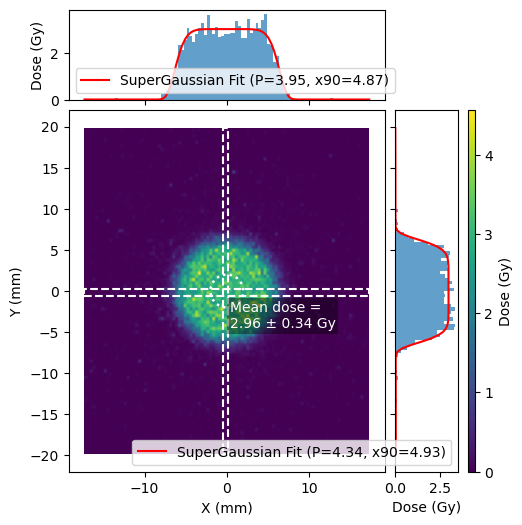

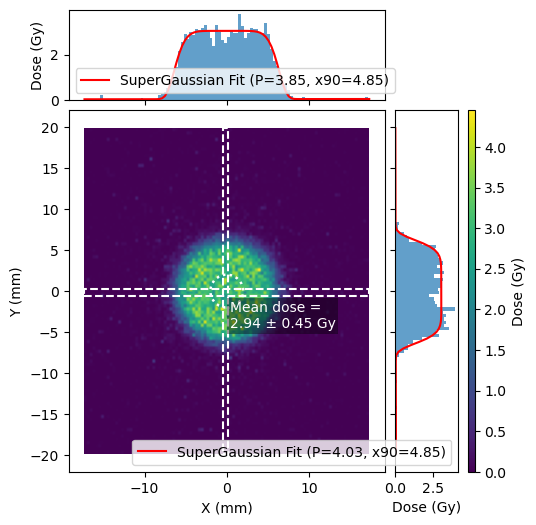

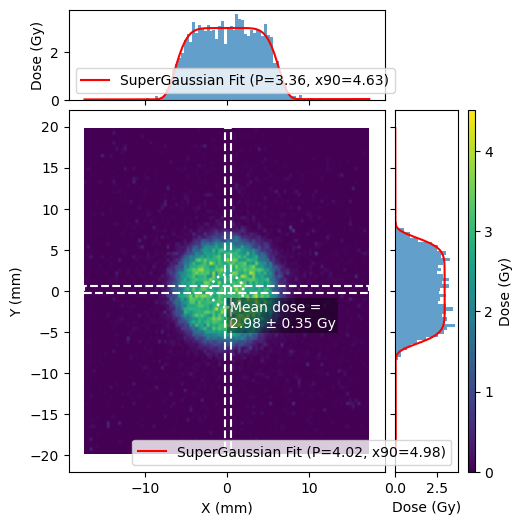

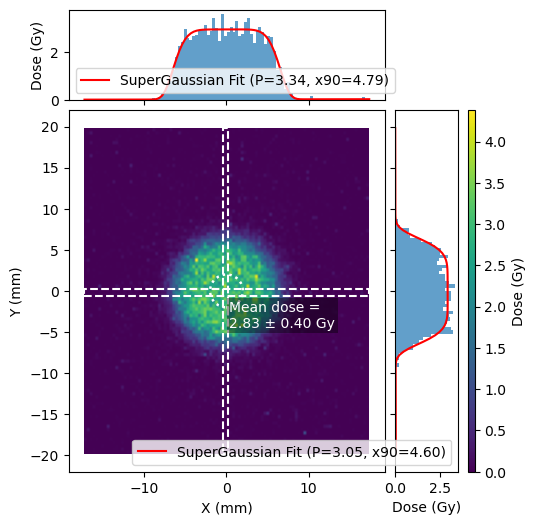

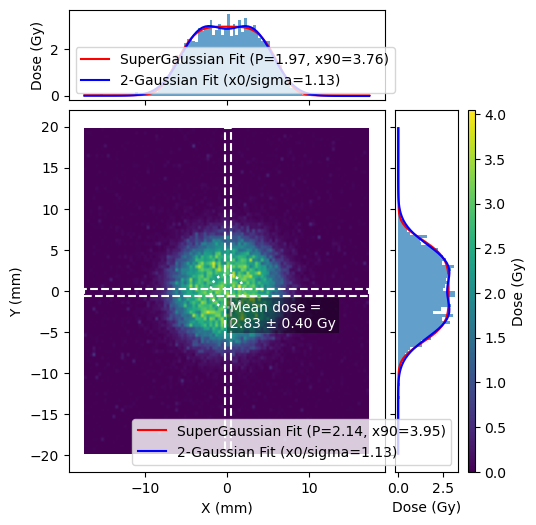

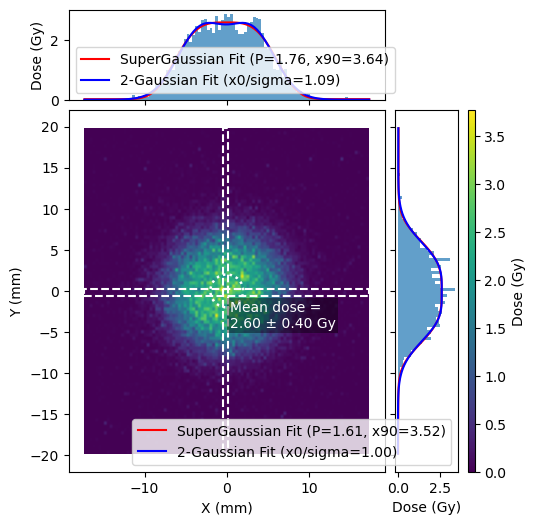

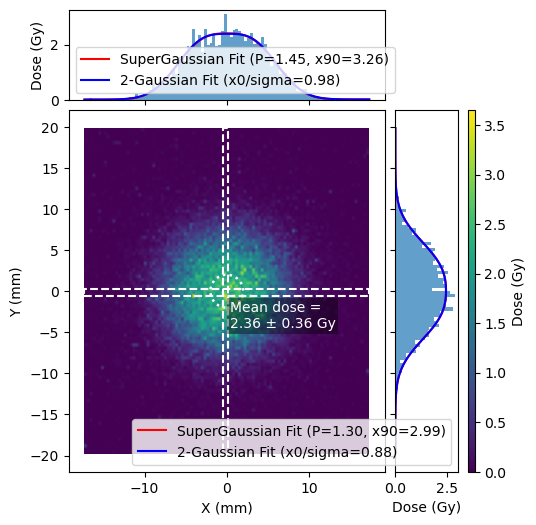

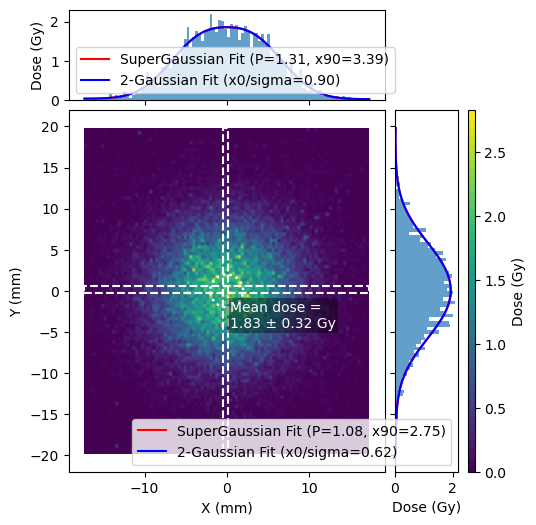

In [ ]:
# n_particles = 1000000
# dose_depth = 100
charge = 10
# output_filename = "CLEAR_dual_0916_YAG_875_full"

doses = []
for dose_depth in [5,10,20,40,80,150,200,298]:
    dose_file = "DoseAtTank"+str(dose_depth)+ "_"+ output_filename+".csv"
    
    # profile = "dose"

    if profile == "intensity":
        # initialise plotting class
        plotter = partrec_foil_plotting('patient_beam.phsp' ) #filename defined inside partrec_gaussian_optimiser_utils
        # plot transverse distributions and energy spectrum at patient
        plotter.show_transverse_beam(output_filename, s1_l, s2_depth, s2_width,particle= 'e',fov= 30, col=5,n_bins=120)
        plotter.show_transverse_beam(output_filename, s1_l, s2_depth, s2_width,particle= 'y',fov=30, col=5,n_bins=120)

    elif profile == "dose":

        # dose_file = "DoseAtTank"+str(dose_depth)+ "_"+ output_filename+".csv"
        
            # peek at the scorer to see if it's multibin in z (depth)
            _raw = BinnedResult(dose_file).data['Sum']
            nz = _raw.shape[2] if _raw.ndim == 3 else 1
            if nz > 1:
                z_centers = BinnedResult(dose_file).dimensions[2].get_bin_centers() * 10  # mm
                for i in range(nz):
                    x, y, doseMap = getDosemap(dose_file, n_particles, dose_depth=z_centers[i],
                        outputFileName=output_filename, acChargenC=charge, plot=False, z_index=i)
                    
                    fig, new_cx_idx, new_cy_idx, dose_centre, P_x, P_y, x90_x, x90_y, ratio_x, ratio_y, err_dose, err_Px, err_Py, err_x90_x, err_x90_y,err_ratio_x, err_ratio_y = plot_dose1( doseMap, "RCF",x, y,strip_width=2)
                    doses.append(dose_centre)
                # plt.savefig('Output_figs/' + output_filename + f"_z{z_centers[i]:.1f}mm_dose_map.png")
            else:
                x, y, doseMap = getDosemap(
                    dose_file, n_particles, dose_depth, output_filename, acChargenC=charge, plot=False
                )
                fig, new_cx_idx, new_cy_idx, dose_centre, P_x, P_y, x90_x, x90_y, ratio_x, ratio_y, err_dose, err_Px, err_Py, err_x90_x, err_x90_y ,err_ratio_x, err_ratio_y= plot_dose1( doseMap, "RCF",x, y,strip_width=2)
            
                doses.append(dose_centre)
                # plt.savefig('Output_figs/' + output_filename + "_dose_map.png")




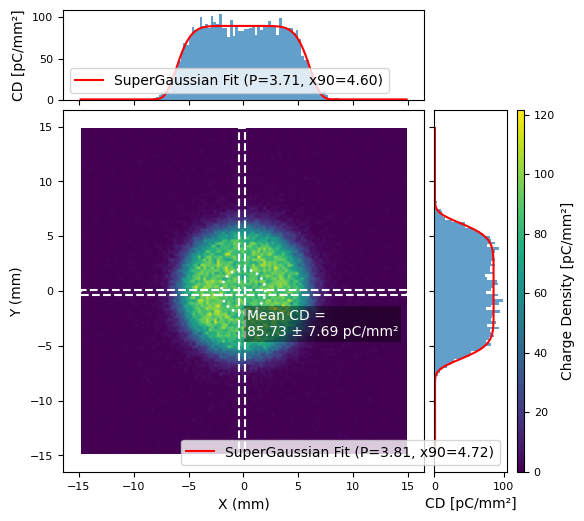

In [74]:
# Charge density map straight from the phase-space file (patient_beam.phsp), instead
# of from a dose map. Each row in the phsp is one simulated electron (PDG==11) --
# histogramming their (X,Y) positions and normalizing to the real bunch charge gives
# charge density directly, no dose/stopping-power conversion needed.
output_filename = "CLEAR_dual_scatterer_0515_small_col_10mm"
Q_total_pC = population / RF_Track.nC * 1000  # pC -- derived from the bunch charge used to track R above; EDIT ME to override
Q_total_pC = 10400  # pC charge on THz2

fov = 15      # mm, field of view (matches show_transverse_beam above)
n_bins = 120  # matches show_transverse_beam above

plotter = partrec_foil_plotting('patient_beam.phsp' )
phsp_e = plotter.phsp_dict['e']

hist2d, xedges, yedges = np.histogram2d(
    phsp_e["X"], phsp_e["Y"], bins=n_bins, range=[[-fov, fov], [-fov, fov]],
    weights=phsp_e["Weight"]
)

x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
pixel_area_mm2 = (xedges[1] - xedges[0]) * (yedges[1] - yedges[0])

total_weight = phsp_e["Weight"].sum()  # all electrons at this plane, not just those inside fov

charge_density_map = hist2d.T * Q_total_pC / total_weight / pixel_area_mm2

fig, cx, cy, CD_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, CD_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1(
    charge_density_map, "YAG", x_centers, y_centers, strip_width=2
)
plt.savefig(f'CLEAR_experiments/Aug2026/Simulations/large_0820/{output_filename}_charge_density_map.png')

In [ ]:
chargenC = 10.37 #10.2 for 15 May, 12.3 for 13 May
dose_depth = 100 #robot depth -25
n_particles = int(3e6)
csv_path = "CLEAR_experiments/Sep2026/16_05_2026dual_water_col_sim.csv"
fig_dir = "CLEAR_experiments/Sep2026/Simulations/dual"
output_filename = "CLEAR_dual_0916_YAG_875_full"
# dose_file = "CLEAR_experiments/May2026/DoseAtTank"+str(dose_depth)+ "_"+ output_filename+".csv"
dose_file = "CLEAR_experiments/Sep2026/DoseAtTank100_CLEAR_dual_water_col_0916_YAG_875_full.csv"

os.makedirs(fig_dir, exist_ok=True)

existing_csv_entries = set()

if os.path.exists(csv_path):
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        next(reader, None)  # skip header
        for row in reader:
            if row:
                existing_csv_entries.add(round(float(row[0]), 1))

write_header = not os.path.exists(csv_path) or os.path.getsize(csv_path) == 0

with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow([
            "depth",
            "cx", "cy",
            "dose_centre",
            "P_x", "P_y",
            "r90_x", "r90_y",
            "ratio_x", "ratio_y",
            "dose_std",
            "errPx", "errPy",
            "err_x90_x","err_x90_y",
            "err_ratio_x", "err_ratio_y"
        ])
    

    # peek at the scorer to see if it's multibin in z (depth)
    _raw = BinnedResult(dose_file).data['Sum']
    nz = _raw.shape[2] if _raw.ndim == 3 else 1
    print(nz)
    if nz > 1:
        z_dim = BinnedResult(dose_file).dimensions[2]
        depths = (get_bin_edges(z_dim)[1:] * 10)[::-1]  # back edge of each bin, mm, same length as bin centres
        for i in range(nz):
            depth_i = round(float(depths[i]), 1)
            csv_line_exists = depth_i in existing_csv_entries

            if csv_line_exists:
                print(f"Skipping {depth_i}: CSV entry and image already exist.")
                continue

            x, y, doseMap = getDosemap(
                dose_file, n_particles, dose_depth=depths[i],
                outputFileName=output_filename, acChargenC=chargenC, plot=False, z_index=i
            )
            fig, cx, cy, dose_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1( doseMap, "RCF",x, y, strip_width=2)
            # if i==0 or i==nz-20 or i==nz-50 or i==nz-109 or i==nz-138 or i==nz-158 or i==nz-197 or i==nz-227 or i==nz-256:
            if i==0 or i==nz-20 or i==nz-60 or i==nz-100:
                plt.savefig(os.path.join(fig_dir, output_filename + f"_z{depth_i:.1f}mm_dose_map.png"))
            plt.close(fig)

            writer.writerow([
                depth_i,
                cx, cy,
                dose_centre,
                Px, Py,
                x90_x, x90_y,
                ratio_x, ratio_y,
                dose_std,
                errPx, errPy,
                err_x90_x, err_x90_y,
                err_ratio_x, err_ratio_y
            ])
            existing_csv_entries.add(depth_i)

    else:
        x, y, doseMap = getDosemap(
            dose_file, n_particles, dose_depth, output_filename, acChargenC=chargenC, plot=False
        )
        fig, cx, cy, dose_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1( doseMap, "RCF",x, y,strip_width=2)
 
        writer.writerow([
            20,
            cx, cy,
            dose_centre,
            Px, Py,
            x90_x, x90_y,
            ratio_x, ratio_y,
            dose_std,
            errPx, errPy,
            err_x90_x, err_x90_y,
            err_ratio_x, err_ratio_y
        ])
        plt.savefig(os.path.join(fig_dir, output_filename + '_20mm_dose_map.png'))

100


NameError: name 'get_bin_edges' is not defined

In [ ]:
Q_total_pC = chargenC * 1000  # pC -- EDIT ME: total charge for this simulated pulse (chargenC above is in nC)

csv_path = "CLEAR_experiments/May2026/05_15_2026small_uncol_sim_charge_density.csv"
fig_dir = "CLEAR_experiments/May2026/Simulations/small_0515_charge_density"

os.makedirs(fig_dir, exist_ok=True)

existing_csv_entries = set()

if os.path.exists(csv_path):
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        next(reader, None)  # skip header
        for row in reader:
            if row:
                existing_csv_entries.add(round(float(row[0]), 1))

write_header = not os.path.exists(csv_path) or os.path.getsize(csv_path) == 0

with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow([
            "depth",
            "cx", "cy",
            "CD_centre",
            "P_x", "P_y",
            "r90_x", "r90_y",
            "ratio_x", "ratio_y",
            "CD_std",
            "errPx", "errPy",
            "err_x90_x","err_x90_y",
            "err_ratio_x", "err_ratio_y"
        ])
    

    # peek at the scorer to see if it's multibin in z (depth)
    _raw = BinnedResult(dose_file).data['Sum']
    nz = _raw.shape[2] if _raw.ndim == 3 else 1
    print(nz)
    if nz > 1:
        z_dim = BinnedResult(dose_file).dimensions[2]
        depths = (get_bin_edges(z_dim)[1:] * 10)[::-1]  # back edge of each bin, mm, same length as bin centres
        for i in range(nz):
            depth_i = round(float(depths[i]), 1)
            csv_line_exists = depth_i in existing_csv_entries

            if csv_line_exists:
                print(f"Skipping {depth_i}: CSV entry and image already exist.")
                continue

            # acChargenC here only sets an overall scale that cancels out below when we
            # renormalize to Q_total_pC -- what matters is the map's spatial *shape*,
            # which is proportional to local particle fluence just like the dose map is.
            x, y, doseMap = getDosemap(
                dose_file, n_particles, dose_depth=depths[i],
                outputFileName=output_filename, acChargenC=chargenC, plot=False, z_index=i
            )

            pixel_area_mm2 = np.mean(np.diff(x)) * np.mean(np.diff(y))
            total_dose = np.sum(doseMap)
            chargeDensityMap = doseMap * Q_total_pC / total_dose / pixel_area_mm2

            fig, cx, cy, CD_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, CD_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1( chargeDensityMap, "YAG",x, y, strip_width=2)
            if i==0 or i==nz-20 or i==nz-50 or i==nz-109 or i==nz-138 or i==nz-158 or i==nz-197 or i==nz-227 or i==nz-256:
                plt.savefig(os.path.join(fig_dir, output_filename + f"_z{depth_i:.1f}mm_charge_density_map.png"))
            plt.close(fig)

            writer.writerow([
                depth_i,
                cx, cy,
                CD_centre,
                Px, Py,
                x90_x, x90_y,
                ratio_x, ratio_y,
                CD_std,
                errPx, errPy,
                err_x90_x, err_x90_y,
                err_ratio_x, err_ratio_y
            ])
            existing_csv_entries.add(depth_i)

    else:
        x, y, doseMap = getDosemap(
            dose_file, n_particles, dose_depth, output_filename, acChargenC=chargenC, plot=False
        )
        pixel_area_mm2 = np.mean(np.diff(x)) * np.mean(np.diff(y))
        total_dose = np.sum(doseMap)
        chargeDensityMap = doseMap * Q_total_pC / total_dose / pixel_area_mm2

        fig, cx, cy, CD_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, CD_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1( chargeDensityMap, "YAG",x, y,strip_width=2)
 
        writer.writerow([
            20,
            cx, cy,
            CD_centre,
            Px, Py,
            x90_x, x90_y,
            ratio_x, ratio_y,
            CD_std,
            errPx, errPy,
            err_x90_x, err_x90_y,
            err_ratio_x, err_ratio_y
        ])
        plt.savefig(os.path.join(fig_dir, output_filename + '_20mm_charge_density_map.png'))

In [ ]:
# Dose + charge density maps at 3 depths (20/60/100 mm), one image pair per individual
# charge reading at that depth (not the mean). No CSV output -- images only.
#
# Dose maps use each shot's THz1 charge (acChargenC, matches how films were matched to
# sim dose maps). Charge density maps use THz2 instead -- THz1 was wrong for this: THz1
# and THz2 read very different absolute charges for the same shot (see TIMBER_charge_plot.ipynb),
# and cross-checking against the E4/XD film charge-density fits confirmed THz2 is the one
# that agrees with film.

# depth_thz1_charge = { #dual scattering water
#     20:  [5.281835, 10.374534, 16.072928, 5.854826],
#     60:  [5.870332, 10.978262, 16.019594],
#     100: [5.916073, 10.792282, 16.549864],
# }
# depth_thz2_charge = { #dual scattering water
#     20:  [2.158767, 4.219742, 6.518475, 2.392730],
#     60:  [2.368442, 4.434310, 6.478955],
#     100: [2.391266, 4.392778, 6.600579],
# }
# depth_thz1_charge = { #dual scattering air
#     20:  [7.269488, 10.960515, 16.496210],
#     60:  [5.780955, 10.712282, 15.824420],
#     100: [5.669943, 10.587868, 16.234666],
# }
# depth_thz2_charge = { #dual scattering air
#     20:  [2.961421, 4.461892, 6.720145],
#     60:  [2.359248, 4.381068, 6.473832],
#     100: [2.320186, 4.349004, 6.644078],
# }
# depth_thz1_charge = { #quad water col
#     20:  [6.125381, 12.101969, 18.503668],
#     60:  [6.004077, 11.846508, 18.389042],
#     100: [5.963643, 11.893804, 18.054863],
# }

# depth_thz1_charge = { #quad water uncol
#     20:  [6.118749, 11.892752, 18.152656],
#     60:  [6.077765, 11.920242, 18.222639],
#     100: [6.040075, 11.897600, 18.266641],
# }

depth_thz1_charge = { #dual scattering set pre scat only
    20: [2.153782, 4.296494, 6.501780],
}
depth_thz2_charge = { #dual scattering set pre scat only
    20: [2.168327, 4.335968, 6.566502],
}

n_particles = int(3e6)
output_filename = "CLEAR_prescatterer_uncol_0916_YAG"
dose_file = "CLEAR_experiments/Sep2026/DoseAtTank20_CLEAR_pre_scatterer_0916.csv"
fig_dir = "CLEAR_experiments/Sep2026/Simulations/dual_scattering"

os.makedirs(fig_dir, exist_ok=True)

z_dim = BinnedResult(dose_file).dimensions[2]
depths = (get_bin_edges(z_dim)[1:] * 10)[::-1]  # back edge of each bin, mm, same length as bin centres

for depth, thz1_charges in depth_thz1_charge.items():
    thz2_charges = depth_thz2_charge[depth]
    i = int(np.argmin(np.abs(depths - depth)))
    depth_i = round(float(depths[i]), 1)

    for charge_idx, (chargenC_thz1, chargenC_thz2) in enumerate(zip(thz1_charges, thz2_charges)):
        x, y, doseMap = getDosemap(
            dose_file, n_particles, dose_depth=depths[i],
            outputFileName=output_filename, acChargenC=chargenC_thz1, plot=False, z_index=i
        )

        tag = f"_z{depth_i:.1f}mm_charge{charge_idx}_{chargenC_thz1:.3f}nC"

        # Dose map
        fig, cx, cy, dose_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1(doseMap, "RCF", x, y, strip_width=2)
        plt.savefig(os.path.join(fig_dir, output_filename + tag + "_dose_map.png"))
        plt.close(fig)

        # Charge density map (same doseMap, renormalized to THz2 charge)
        Q_total_pC = chargenC_thz2 * 1000  # pC
        pixel_area_mm2 = np.mean(np.diff(x)) * np.mean(np.diff(y))
        total_dose = np.sum(doseMap)
        chargeDensityMap = doseMap * Q_total_pC / total_dose / pixel_area_mm2

        fig, cx, cy, CD_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, CD_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1(chargeDensityMap, "RCF", x, y, strip_width=2)
        plt.savefig(os.path.join(fig_dir, output_filename + tag + "_charge_density_map.png"))
        plt.close(fig)
